In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/processed/features.csv")
df.head()

,gender,age,annual_income,score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [3]:
df.count()

gender           200
age              200
annual_income    200
score            200
dtype: int64

In [4]:
q1 = df["score"].quantile(0.25)
q3 = df["score"].quantile(0.75)
iqr = q3 - q1
print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr    

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")


Q1: 34.75
Q3: 73.0
IQR: 38.25
Lower Bound: -22.625
Upper Bound: 130.375


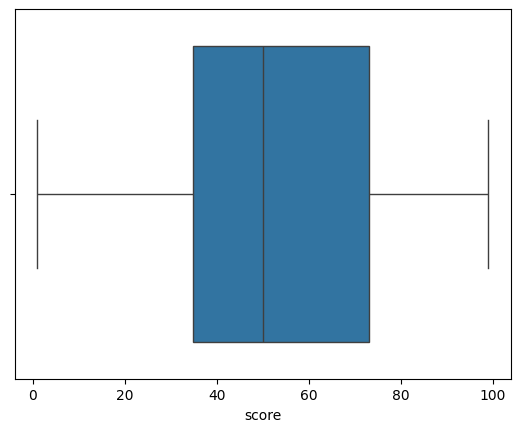

In [5]:
# Visualización de outliers
sns.boxplot(x=df["score"])
plt.show()

/var/folders/mb/5h2z1kh519b51ng867g720k80000gn/T/ipykernel_11175/673237163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_count_gender.index, y=df_count_gender.values, palette=colors)


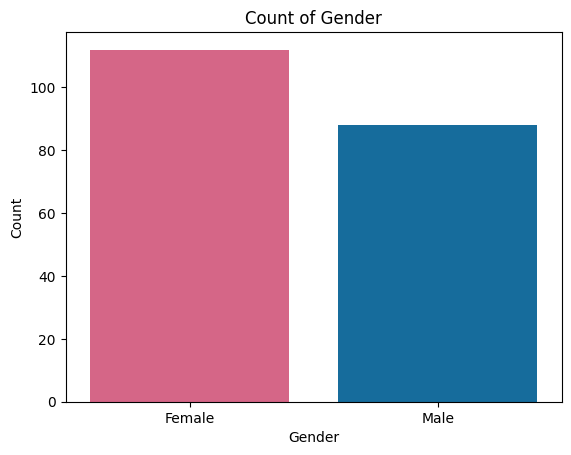

In [6]:
df_count_gender = df["gender"].value_counts()
colors = ["#e75480", "#0072b2"] 
sns.barplot(x=df_count_gender.index, y=df_count_gender.values, palette=colors)
plt.title("Count of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

/var/folders/mb/5h2z1kh519b51ng867g720k80000gn/T/ipykernel_11175/2526684993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_score.index, y=df_score.values, palette="viridis")


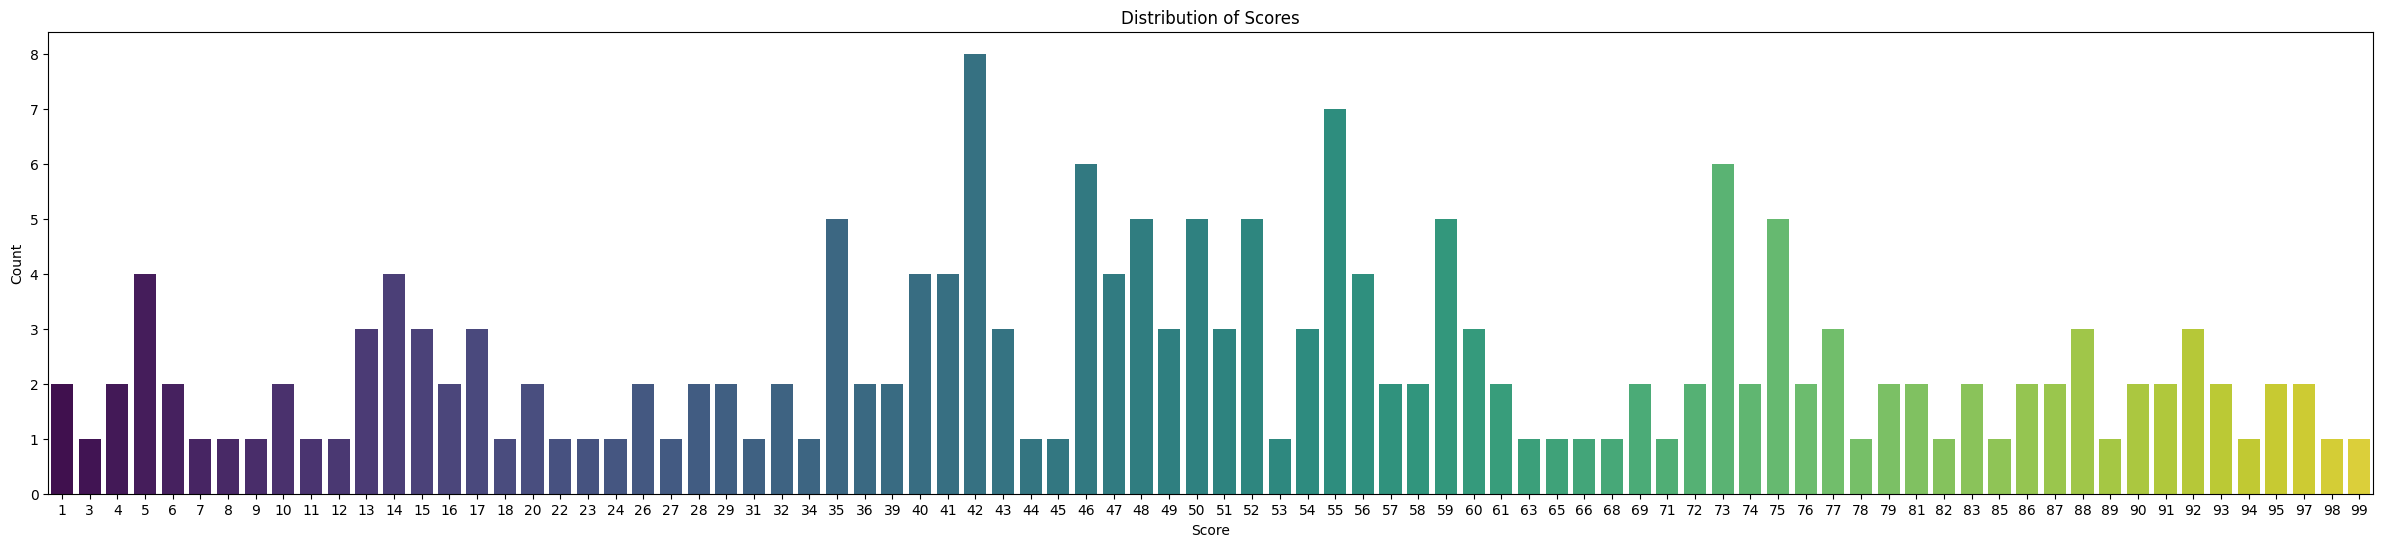

In [51]:
df_score = df["score"].value_counts(ascending=False).sort_index()
plt.figure(figsize=(30, 6))
sns.barplot(x=df_score.index, y=df_score.values, palette="viridis")
plt.title("Distribution of Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

/var/folders/mb/5h2z1kh519b51ng867g720k80000gn/T/ipykernel_11175/2111528165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x=df_stats.index, y=stat, palette=colors, label=stat, legend=False, ax=ax[stat])
/var/folders/mb/5h2z1kh519b51ng867g720k80000gn/T/ipykernel_11175/2111528165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x=df_stats.index, y=stat, palette=colors, label=stat, legend=False, ax=ax[stat])
/var/folders/mb/5h2z1kh519b51ng867g720k80000gn/T/ipykernel_11175/2111528165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

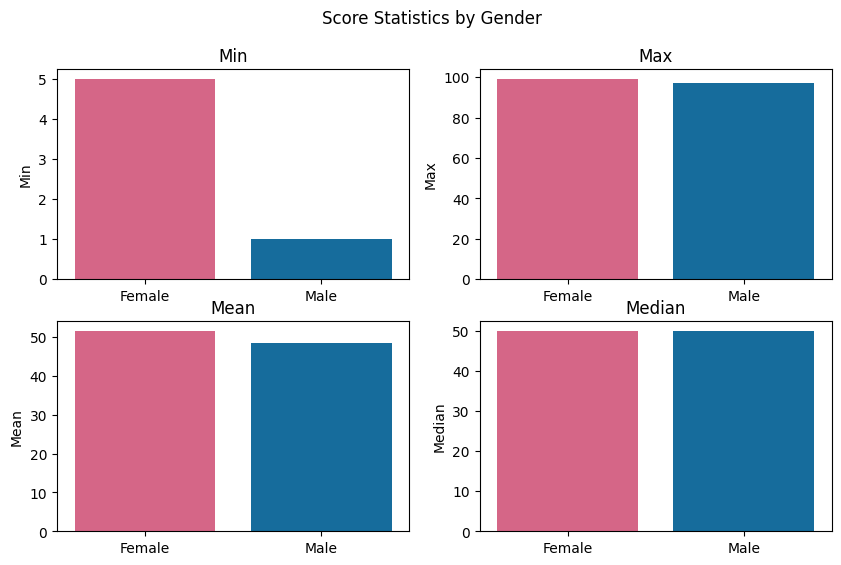

In [50]:
stats = ["mean", "median", "min", "max"]
df_stats= df.groupby("gender")["score"].agg(stats)

fig, ax = plt.subplot_mosaic([["min", "max"],["mean", "median"]], sharey=False, sharex=False,figsize=(10, 6))
for i, stat in enumerate(stats):
    sns.barplot(data=df_stats, x=df_stats.index, y=stat, palette=colors, label=stat, legend=False, ax=ax[stat])
    ax[stat].set_title(stat.capitalize())
    ax[stat].set_xlabel("")
    ax[stat].set_ylabel(stat.capitalize())
plt.suptitle("Score Statistics by Gender")
plt.show()


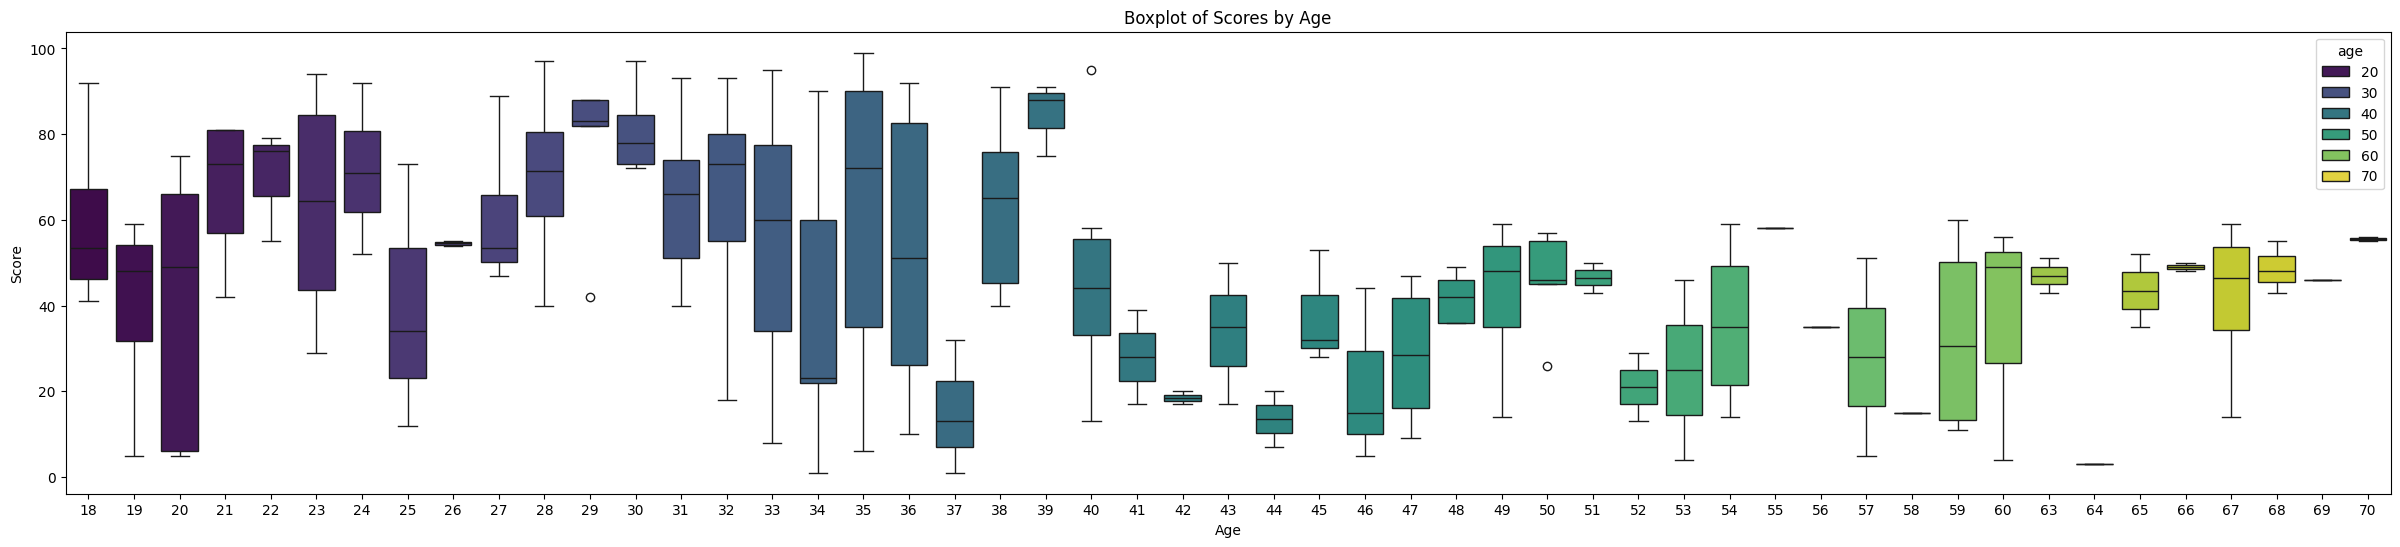

In [65]:
df_age = df[["age", "score"]].value_counts(ascending=False).sort_index()
fig, ax = plt.subplots(figsize=(30, 6))
sns.boxplot(x=df["age"], y=df["score"], palette="viridis", ax=ax, hue=df["age"],  dodge=False)
plt.title("Boxplot of Scores by Age")
plt.xlabel("Age")
plt.ylabel("Score")
plt.show()